In [ ]:
import pandas as pd

df = pd.read_csv("Dataset .csv")
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [ ]:
df.isnull().sum()

,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0
Cuisines,9


In [ ]:
df['Cuisines'] = df['Cuisines'].fillna('Unknown')

In [ ]:
data = df[['Average Cost for two',
           'Price range',
           'Votes',
           'Aggregate rating']]

data.head()

,Average Cost for two,Price range,Votes,Aggregate rating
0,1100,3,314,4.8
1,1200,3,591,4.5
2,4000,4,270,4.4
3,1500,4,365,4.9
4,1500,4,229,4.8


In [ ]:
X = data[['Average Cost for two',
          'Price range',
          'Votes']]

y = data['Aggregate rating']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 1.7599302405948396
R2 Score: 0.22678120947295188


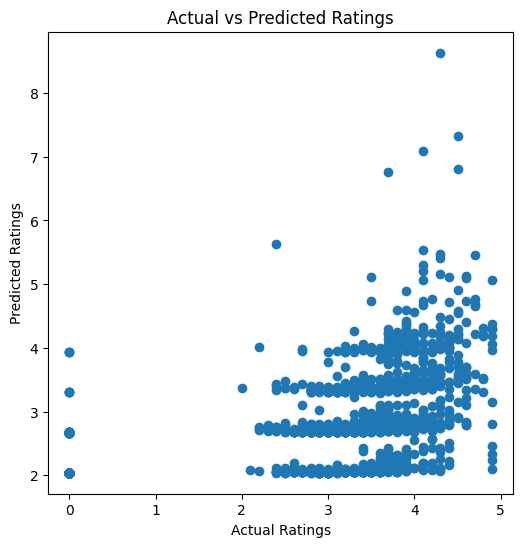

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")

plt.title("Actual vs Predicted Ratings")

plt.show()

In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(importance)

                Feature  Coefficient
0  Average Cost for two     0.000001
1           Price range     0.629687
2                 Votes     0.000704


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

from sklearn.metrics import r2_score

print("R2 Score:", r2_score(y_test, rf_pred))

R2 Score: 0.9363212239144014


In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                Feature  Importance
2                 Votes    0.975561
0  Average Cost for two    0.019270
1           Price range    0.005169


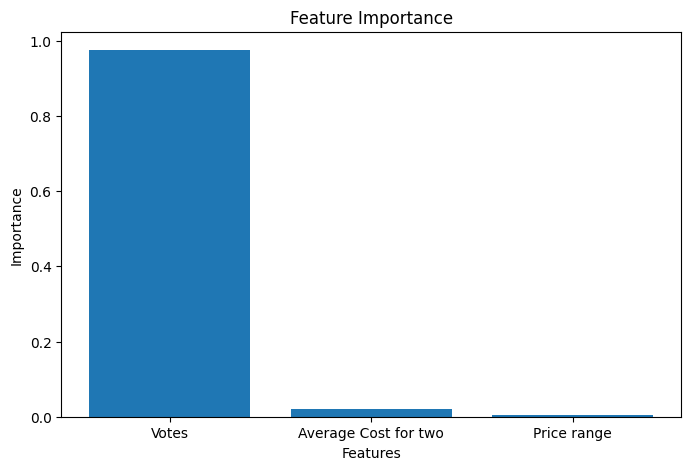

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    importance['Feature'],
    importance['Importance']
)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()

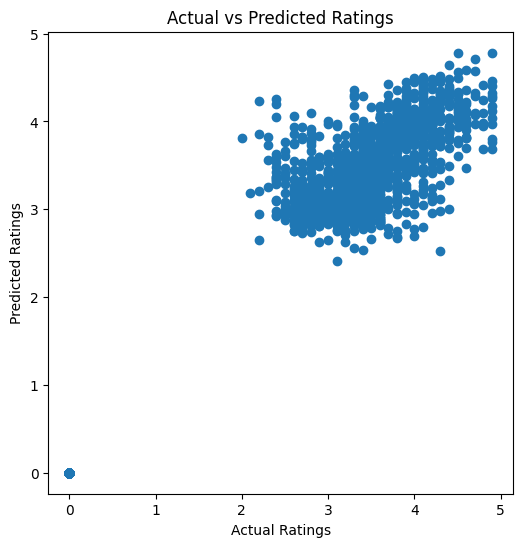

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")

plt.title("Actual vs Predicted Ratings")

plt.show()

# Task 4: Location-Based Analysis


In [ ]:
city_count = df['City'].value_counts().head(10)

print(city_count)

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Lucknow           21
Ahmedabad         21
Amritsar          21
Guwahati          21
Name: count, dtype: int64


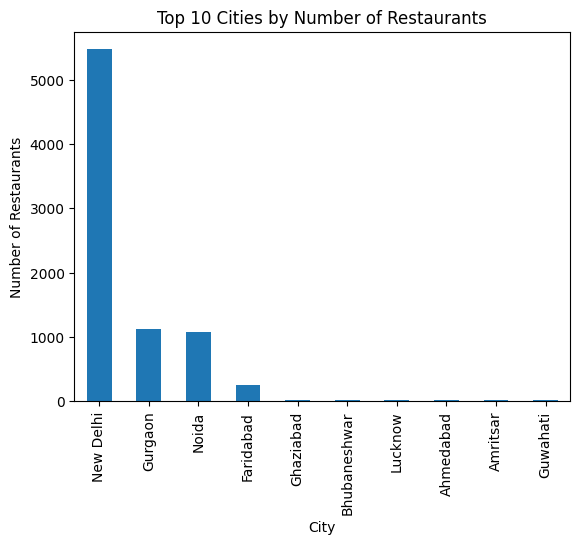

In [ ]:
import matplotlib.pyplot as plt

city_count.plot(kind='bar')

plt.title("Top 10 Cities by Number of Restaurants")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")

plt.show()

In [ ]:
city_rating = df.groupby('City')['Aggregate rating'].mean()

top_rated = city_rating.sort_values(
    ascending=False
).head(10)

print(top_rated)

City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
Beechworth          4.600000
London              4.535000
Taguig City         4.525000
Secunderabad        4.500000
Lincoln             4.500000
Name: Aggregate rating, dtype: float64


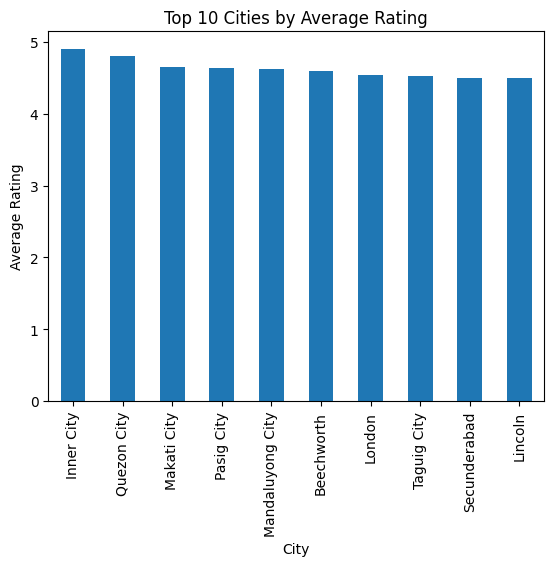

In [ ]:
top_rated.plot(kind='bar')

plt.title("Top 10 Cities by Average Rating")
plt.xlabel("City")
plt.ylabel("Average Rating")

plt.show()

In [ ]:
city_cost = df.groupby('City')['Average Cost for two'].mean()

top_cost = city_cost.sort_values(
    ascending=False
).head(10)

print(top_cost)

City
Jakarta             308437.500000
Tangerang           250000.000000
Bogor               160000.000000
Bandung             150000.000000
Pasay City            3333.333333
Colombo               2375.000000
Mandaluyong City      2000.000000
Panchkula             2000.000000
Taguig City           1725.000000
Hyderabad             1361.111111
Name: Average Cost for two, dtype: float64


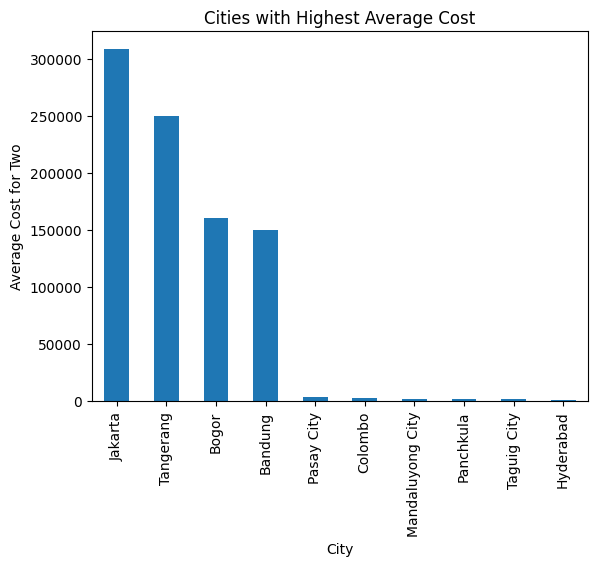

In [ ]:
top_cost.plot(kind='bar')

plt.title("Cities with Highest Average Cost")
plt.xlabel("City")
plt.ylabel("Average Cost for Two")

plt.show()

In [ ]:
city_count = df['City'].value_counts().head(10)

print(city_count)

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Lucknow           21
Ahmedabad         21
Amritsar          21
Guwahati          21
Name: count, dtype: int64


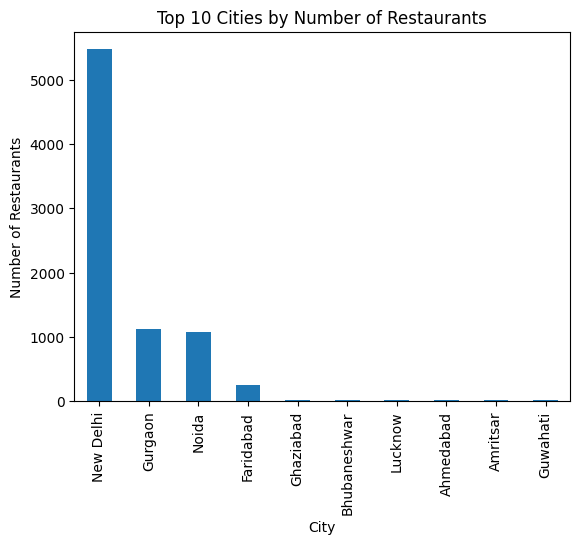

In [ ]:
import matplotlib.pyplot as plt

city_count.plot(kind='bar')

plt.title("Top 10 Cities by Number of Restaurants")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")

plt.show()

In [ ]:
city_rating = df.groupby('City')['Aggregate rating'].mean()

top_rated = city_rating.sort_values(
    ascending=False
).head(10)

print(top_rated)

City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
Beechworth          4.600000
London              4.535000
Taguig City         4.525000
Secunderabad        4.500000
Lincoln             4.500000
Name: Aggregate rating, dtype: float64


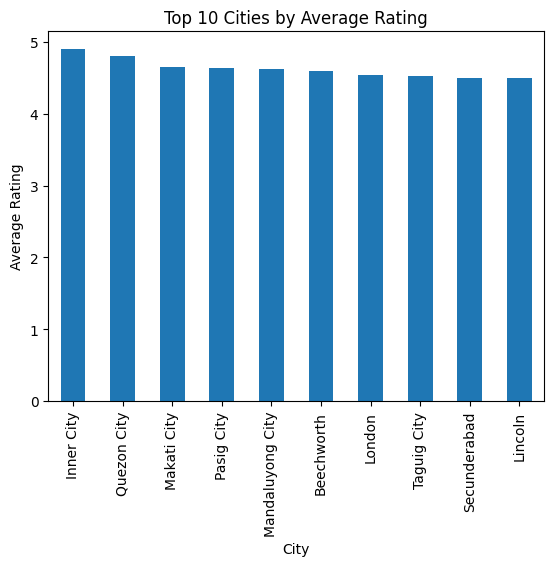

In [ ]:
top_rated.plot(kind='bar')

plt.title("Top 10 Cities by Average Rating")
plt.xlabel("City")
plt.ylabel("Average Rating")

plt.show()

In [ ]:
city_cost = df.groupby('City')['Average Cost for two'].mean()

top_cost = city_cost.sort_values(
    ascending=False
).head(10)

print(top_cost)

City
Jakarta             308437.500000
Tangerang           250000.000000
Bogor               160000.000000
Bandung             150000.000000
Pasay City            3333.333333
Colombo               2375.000000
Mandaluyong City      2000.000000
Panchkula             2000.000000
Taguig City           1725.000000
Hyderabad             1361.111111
Name: Average Cost for two, dtype: float64


Task 3: Cuisine Classification

In [ ]:
df['Main_Cuisine'] = df['Cuisines'].str.split(',').str[0]

df['Main_Cuisine'] = df['Main_Cuisine'].fillna('Unknown')

print(df['Main_Cuisine'].value_counts().head(10))

Main_Cuisine
North Indian    2992
Chinese          855
Fast Food        672
Bakery           621
Cafe             617
American         278
South Indian     262
Mithai           246
Street Food      236
Continental      235
Name: count, dtype: int64


In [ ]:
X_cuisine = df[['Average Cost for two',
                'Price range',
                'Votes',
                'Aggregate rating']]

y_cuisine = df['Main_Cuisine']


from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y_cuisine)


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_cuisine,
    y_encoded,
    test_size=0.2,
    random_state=42
)


from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

clf.fit(X_train, y_train)

# Step 6: Prediction
y_pred = clf.predict(X_test)

# Step 7: Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

# Step 8: Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

Accuracy: 0.25693354264782836
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         0
           2       0.22      0.28      0.25        46
           3       0.00      0.00      0.00         1
           6       0.00      0.00      0.00        13
          11       0.00      0.00      0.00         3
          12       0.08      0.06      0.07       112
          13       0.00      0.00      0.00         5
          14       0.00      0.00      0.00         3
          15       0.10      0.11      0.10        19
          16       0.00      0.00      0.00         1
          17       0.00      0.00      0.00        18
          18       0.25      0.33      0.29         3
          19       0.25      0.12      0.17         8
          20       0.00      0.00      0.00         4
          21       0.00      0.00      0.00        20
          22       0.00      0.00      0.00         3
          23       0.23      0.24      0.23       1

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

                Feature  Importance
2                 Votes    0.539658
3      Aggregate rating    0.224771
0  Average Cost for two    0.201884
1           Price range    0.033687


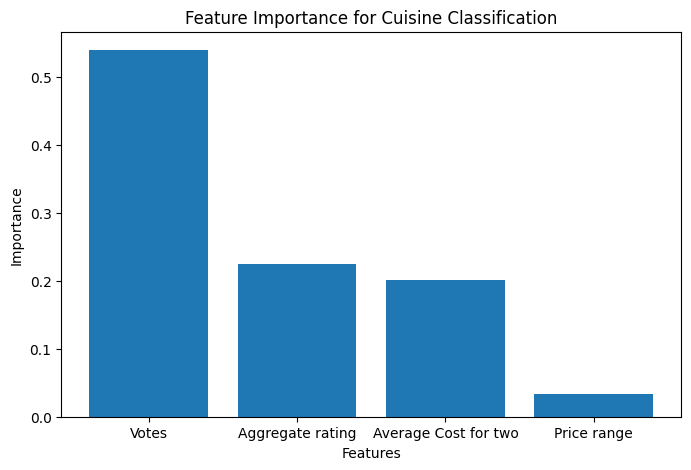

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'Feature': X_cuisine.columns,
    'Importance': clf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

plt.figure(figsize=(8,5))
plt.bar(
    importance['Feature'],
    importance['Importance']
)

plt.title("Feature Importance for Cuisine Classification")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()